# Tesla Delivery Prediction and Demand Analysis

#### Objective

Build an end-to-end Machine Learning pipeline on sales/price data.

# DATA UNDERSTANDING

In [102]:
# import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import (
    RandomizedSearchCV,
    TimeSeriesSplit,
    cross_val_score
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

### load dataset 

In [103]:
df = pd.read_csv("C:\\Users\\dobil\\OneDrive\\Desktop\\Celebal-Excellence-Internship-Program\\week2\\tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [104]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.shape

Rows : 2640
Columns : 12


(2640, 12)

In [105]:
# Data Set information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [106]:
# Statistical Analaysis
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


### checking for missing values 

In [107]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

### checking for duplicate rows


In [108]:
print(
    "Duplicate Rows :",
    df.duplicated().sum()
)

Duplicate Rows : 0


In [109]:
df.dtypes

Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

In [110]:
for col in [
    "Region",
    "Model",
    "Source_Type"
]:
    print("\n", col)
    print(df[col].value_counts())


 Region
Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

 Model
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

 Source_Type
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64


### quality report

In [111]:
quality_report = pd.DataFrame({
    "Metric":[
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows"
    ],
    "Value":[
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})
quality_report

,Metric,Value
0,Rows,2640
1,Columns,12
2,Missing Values,0
3,Duplicate Rows,0


# Data Understanding Insights
- The dataset contains 2,640 observations and 12 features, providing sufficient information for machine learning analysis.
- No missing values or duplicate records were identified, indicating high-quality and well-maintained data.
- The dataset contains a balanced representation of regions and Tesla vehicle models, reducing the risk of sampling bias.

# EXPLORATORY DATA ANALYSIS

## Univariate Analysis

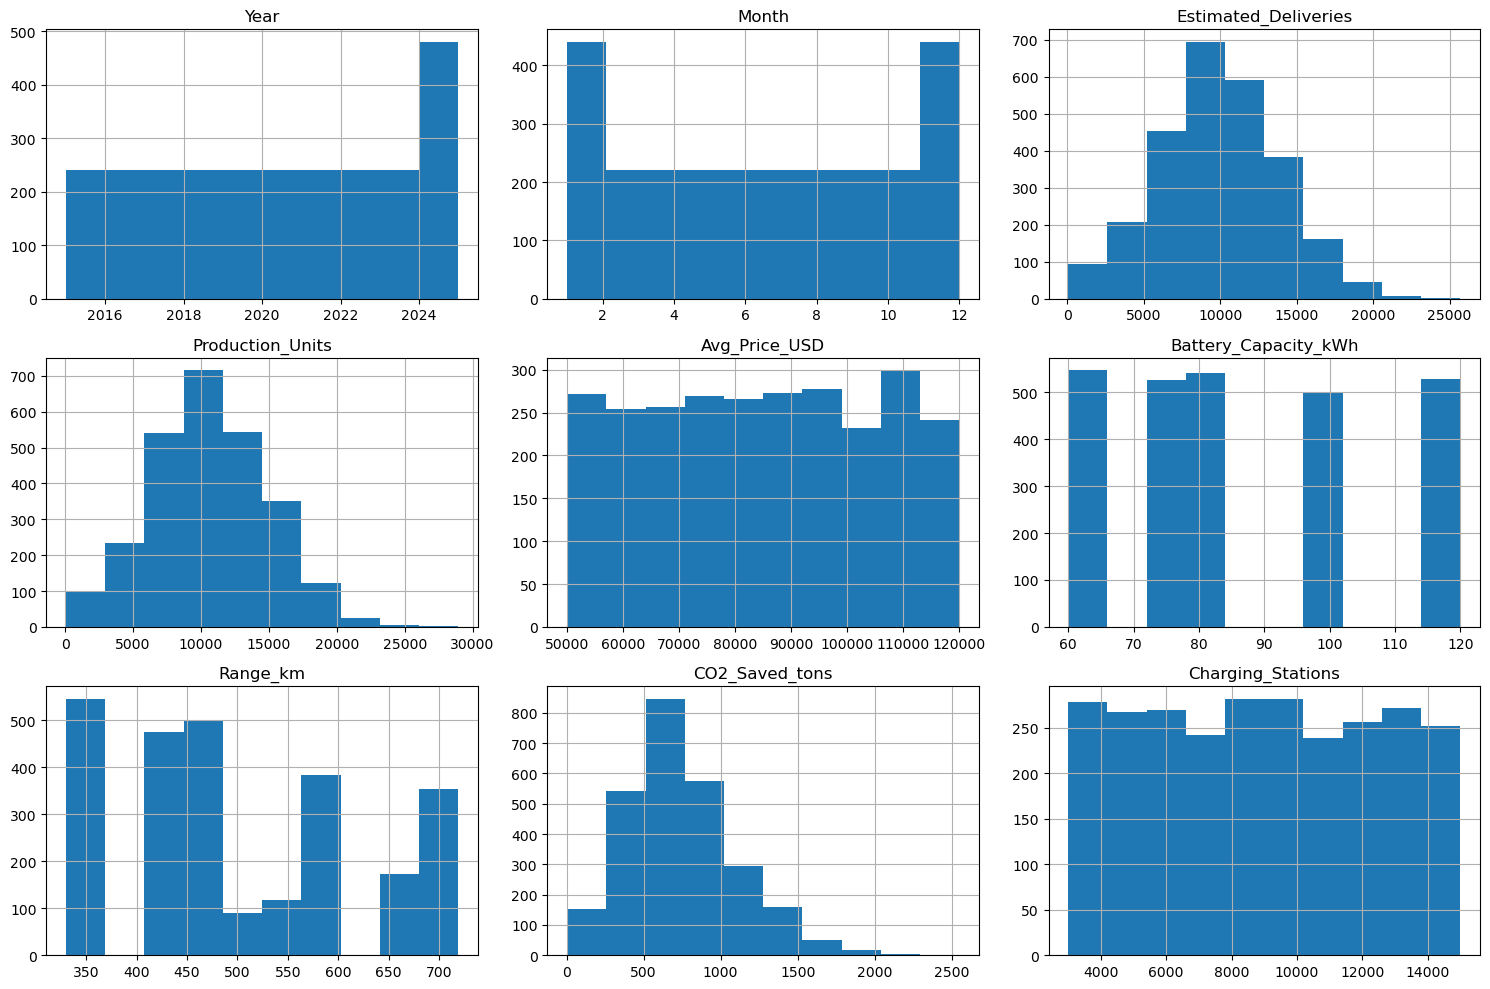

In [112]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

df[numeric_cols].hist(
    figsize=(15,10)
)

plt.tight_layout()

plt.show()

- Most numerical variables show a broad distribution, indicating variation in production, deliveries, pricing, and infrastructure across         different periods.


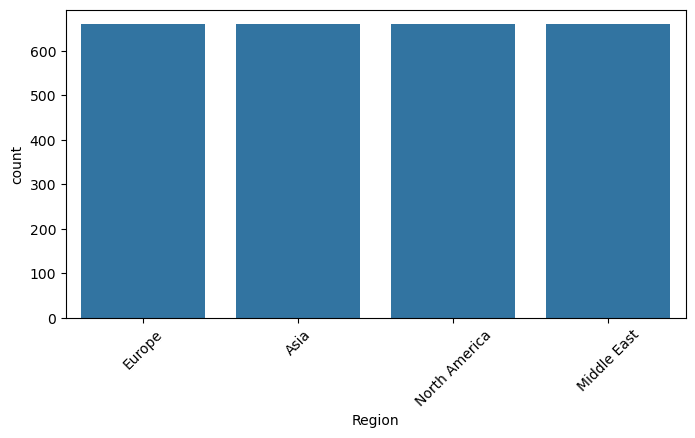

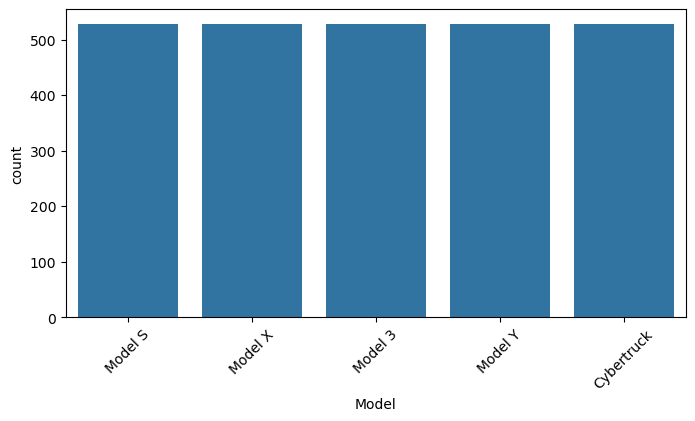

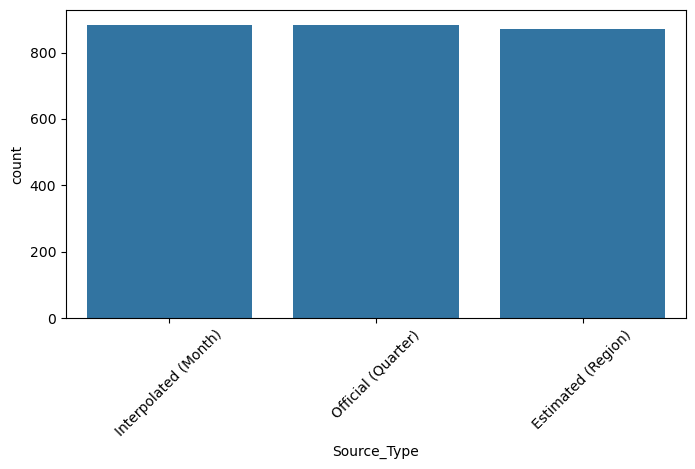

In [113]:
for col in [
    "Region",
    "Model",
    "Source_Type"
]:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=col
    )

    plt.xticks(rotation=45)

    plt.show()

#### Region 
- All regions contain an equal number of observations, ensuring balanced regional representation.
#### Model
- Each Tesla model appears with similar frequency, minimizing model-specific sampling bias.

## NUMERICAL vs NUMERICAL ANALYSIS

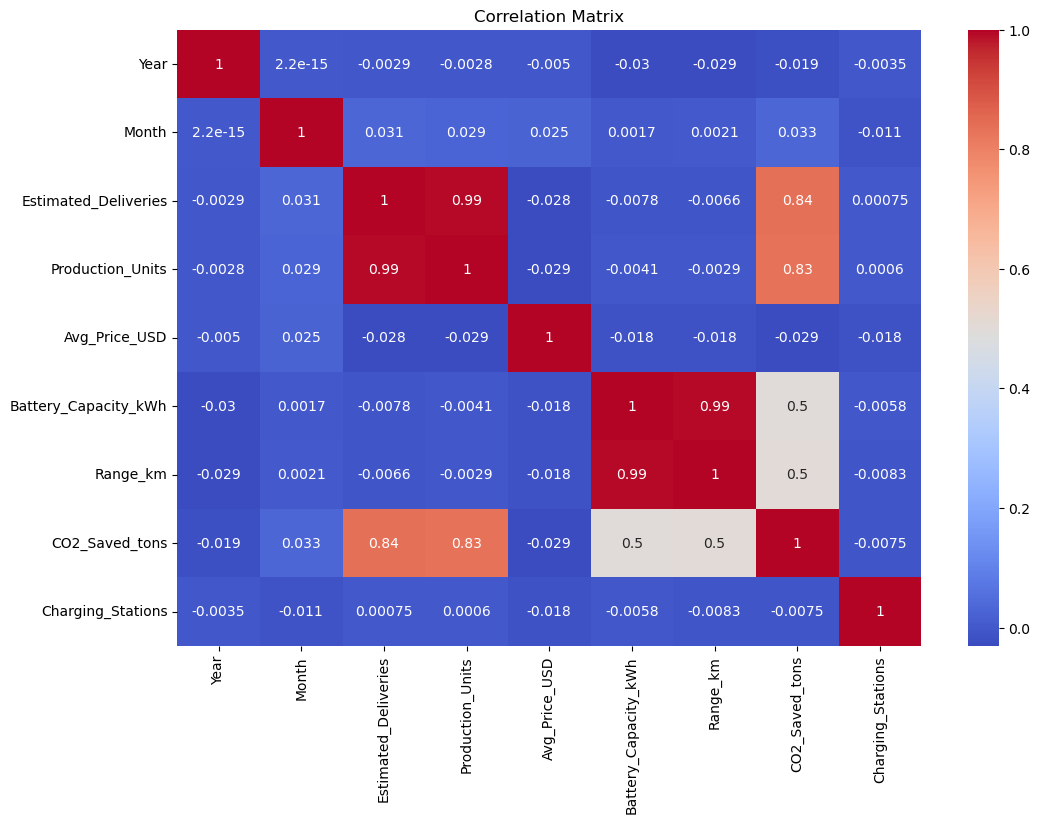

In [114]:
plt.figure(figsize=(12,8))

sns.heatmap(

    df.select_dtypes(
        include=np.number
    ).corr(),

    annot=True,

    cmap="coolwarm"

)

plt.title(
    "Correlation Matrix"
)

plt.show()

- Production Units show a strong positive correlation with Estimated Deliveries, indicating that production capacity directly influences delivery volume.

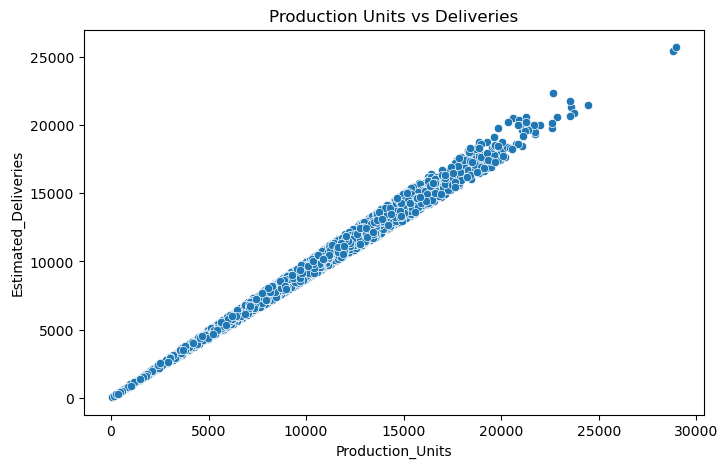

In [115]:
#production_unit vs Deliveries
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Production_Units",y="Estimated_Deliveries")
plt.title("Production Units vs Deliveries")
plt.show()

- A clear positive relationship exists between production and deliveries, confirming production capacity as a major business driver.

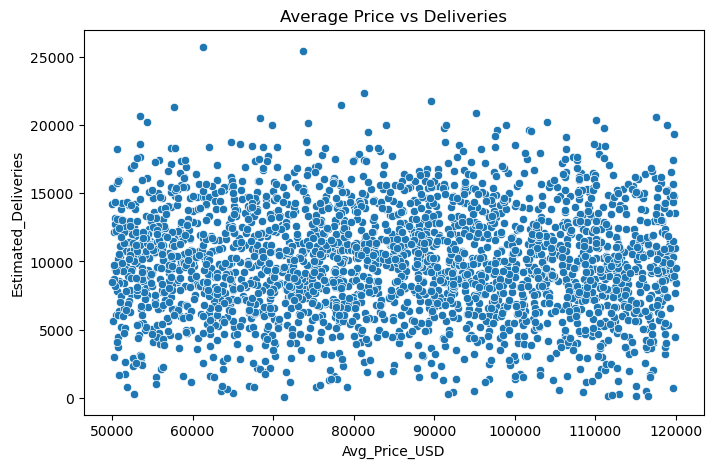

In [116]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Avg_Price_USD",y="Estimated_Deliveries")
plt.title("Average Price vs Deliveries")
plt.show()

- The relationship between vehicle price and deliveries appears weaker than production-related variables.

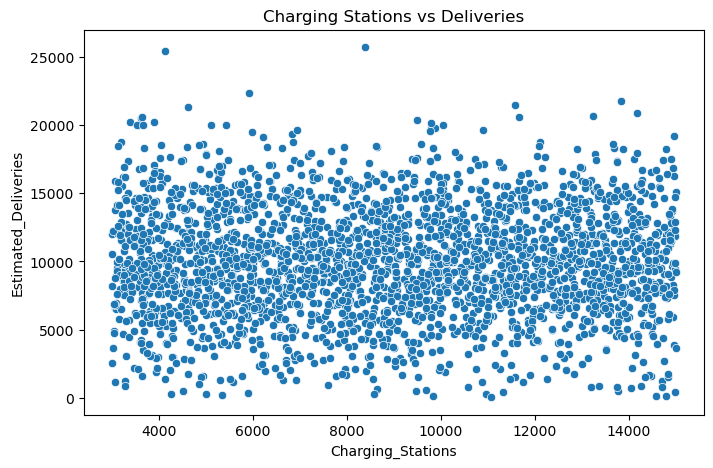

In [117]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Charging_Stations",y="Estimated_Deliveries")
plt.title("Charging Stations vs Deliveries")
plt.show()

- Regions with larger charging infrastructure tend to report higher delivery volumes.

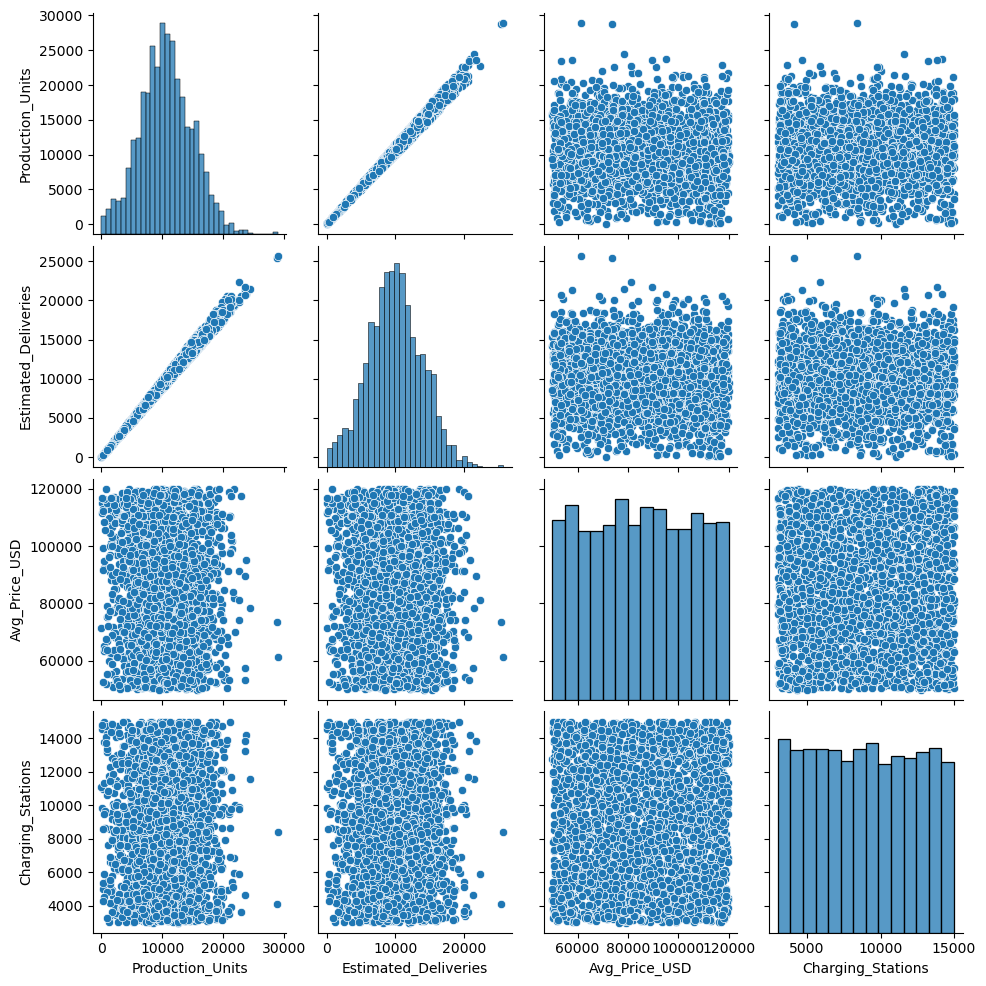

In [118]:
important_cols = [
    "Production_Units",
    "Estimated_Deliveries",
    "Avg_Price_USD",
    "Charging_Stations"
]
sns.pairplot(df[important_cols])
plt.show()

## CATEGORY vs NUMERICAL ANALYSIS

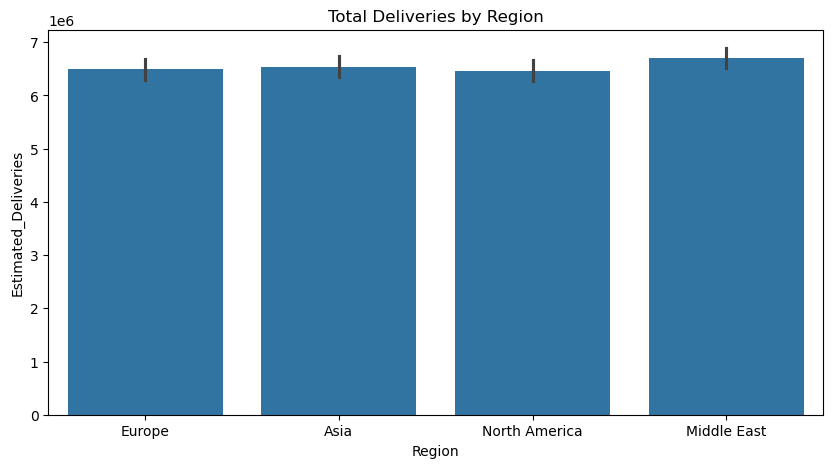

In [119]:
#Region vs Deliveries
plt.figure(figsize=(10,5))
sns.barplot(data=df,x="Region",y="Estimated_Deliveries",estimator=np.sum)
plt.title("Total Deliveries by Region")
plt.show()

- Delivery volumes vary across regions, highlighting differences in market demand and adoption rates.

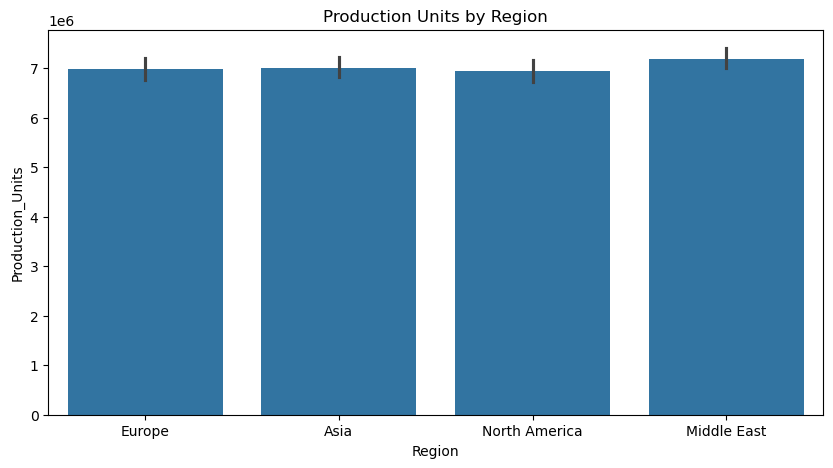

In [120]:
#Region vs Production Units
plt.figure(figsize=(10,5))
sns.barplot(data=df,x="Region",y="Production_Units",estimator=np.sum)
plt.title("Production Units by Region")
plt.show()

- Production allocation differs across regions, suggesting regional demand influences operational planning.

In [121]:
#Create Revenue Feature
df["Revenue"] = (df["Estimated_Deliveries"]*df["Avg_Price_USD"])

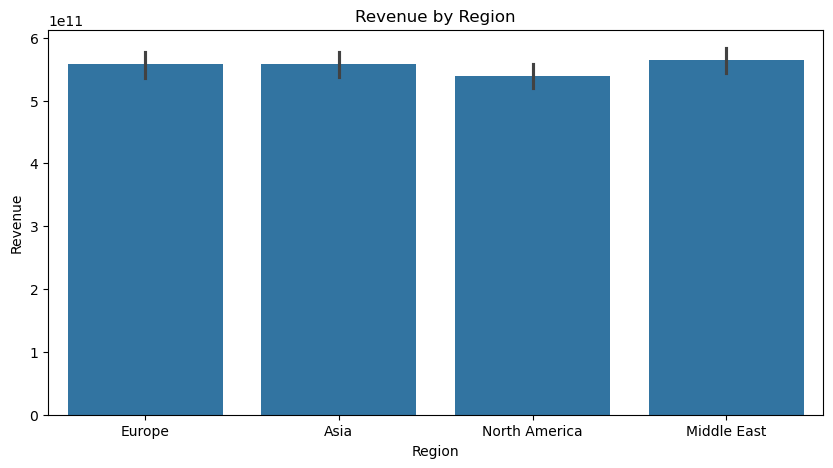

In [122]:
    #Region vs Revenue
plt.figure(figsize=(10,5))
sns.barplot(data=df,x="Region",y="Revenue",estimator=np.sum)
plt.title("Revenue by Region")
plt.show()

- Revenue generation varies across regions due to differences in delivery volume and vehicle pricing.

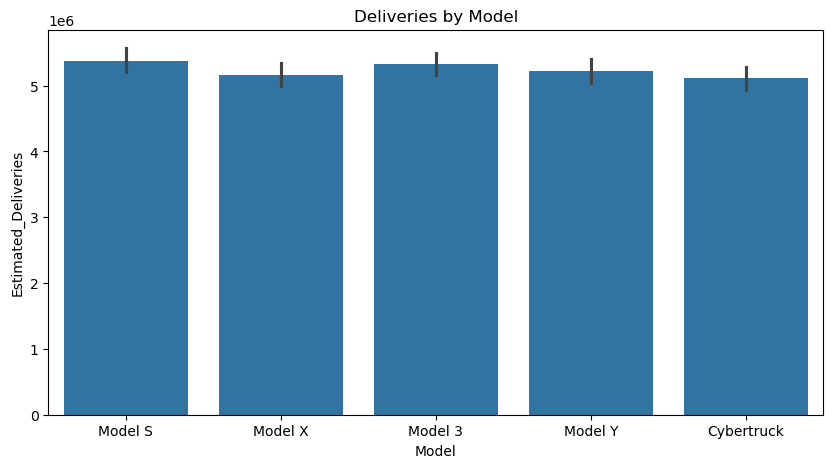

In [123]:
#Model vs Deliveries
plt.figure(figsize=(10,5))
sns.barplot(data=df,x="Model",y="Estimated_Deliveries",estimator=np.sum)
plt.title("Deliveries by Model")
plt.show()

- Delivery performance differs among Tesla models, indicating varying customer preferences.

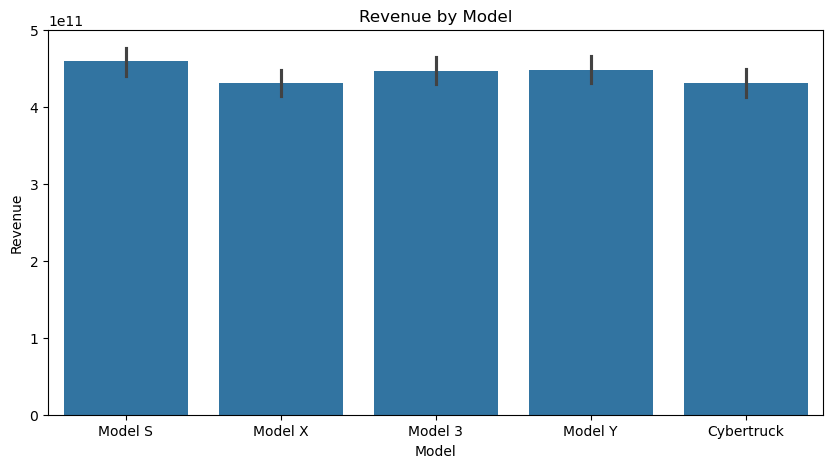

In [124]:
#Model vs Revenue
plt.figure(figsize=(10,5))
sns.barplot(data=df,x="Model",y="Revenue",estimator=np.sum)
plt.title("Revenue by Model")
plt.show()

- Revenue contribution varies by model due to differences in pricing and demand.

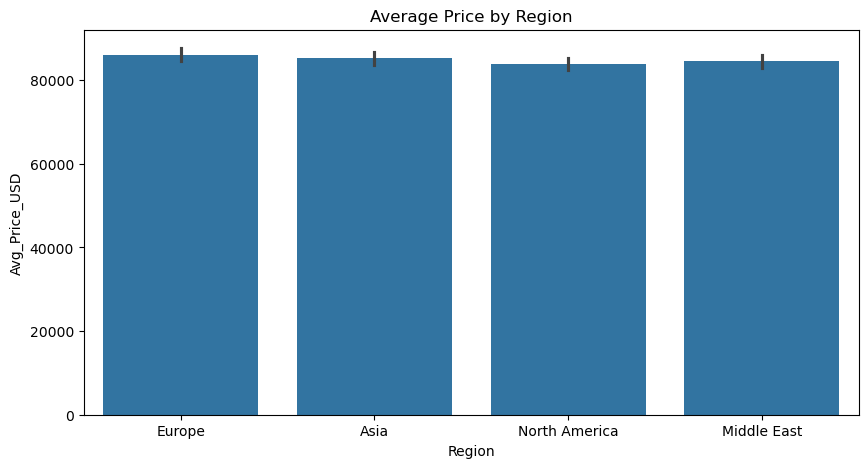

In [125]:
#Region vs Average Price
plt.figure(figsize=(10,5))
sns.barplot(data=df,x="Region",y="Avg_Price_USD")
plt.title("Average Price by Region")
plt.show()

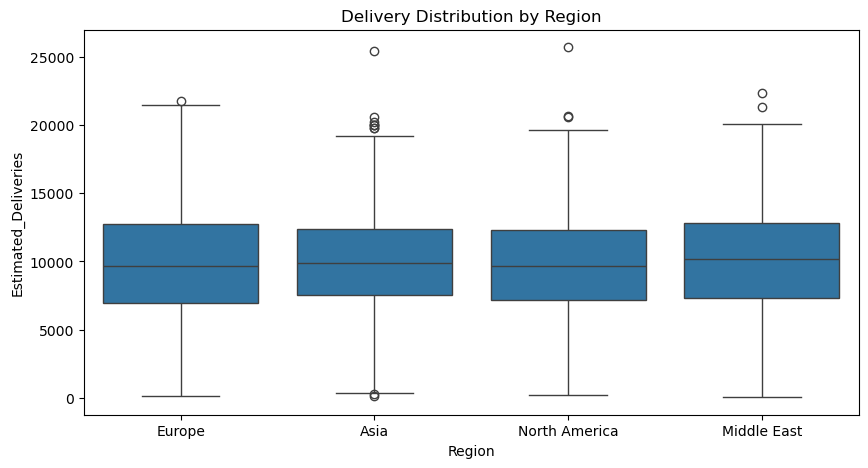

In [126]:
#Region Delivery Distribution
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x="Region",y="Estimated_Deliveries")
plt.title("Delivery Distribution by Region")
plt.show()

- Some regions show wider delivery ranges, suggesting more volatile demand patterns.

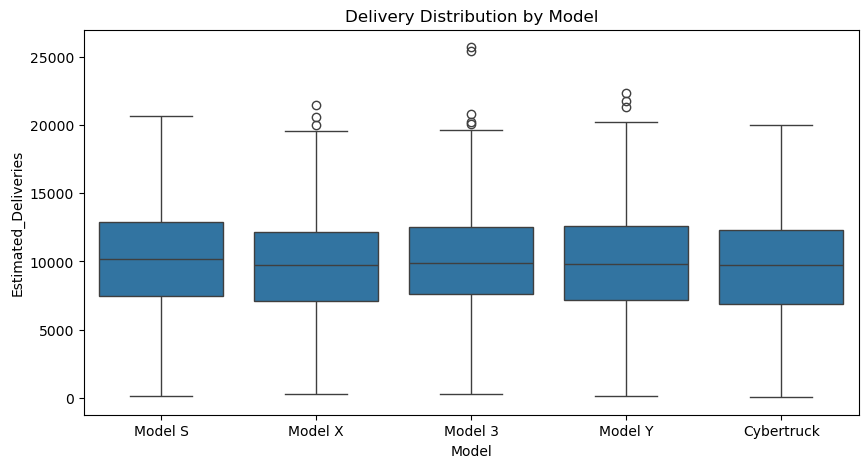

In [127]:
#Model Delivery Distribution
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x="Model",y="Estimated_Deliveries")
plt.title("Delivery Distribution by Model")
plt.show()

- Variations across models indicate changing customer preferences and market dynamics.

## CATEGORY vs CATEGORY ANALYSIS


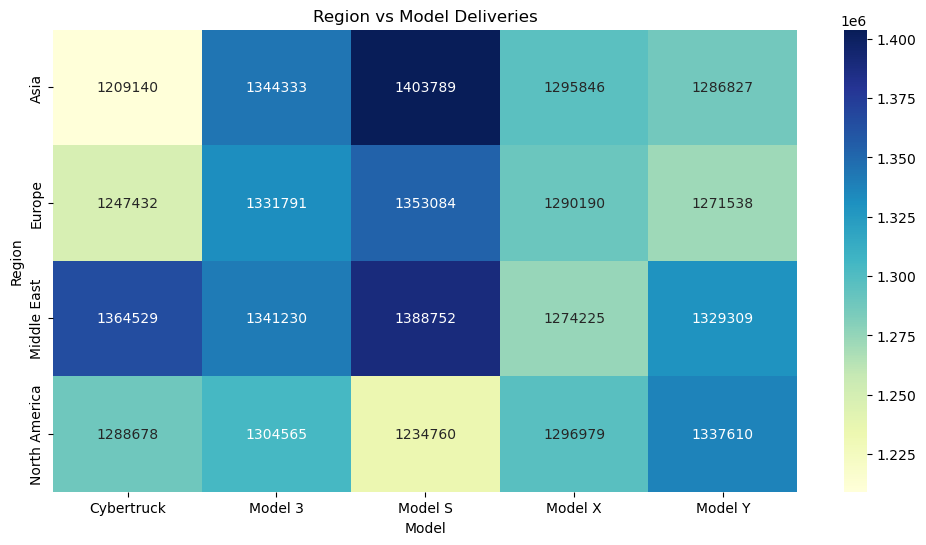

In [128]:
#Region vs Model Deliveries Heatmap
pivot = pd.pivot_table(df,
    values="Estimated_Deliveries",
    index="Region",
    columns="Model",
    aggfunc="sum"
)
plt.figure(figsize=(12,6))
sns.heatmap(pivot,annot=True,fmt=".0f",cmap="YlGnBu")
plt.title("Region vs Model Deliveries")
plt.show()

- Some region-model combinations contribute significantly more deliveries than others.

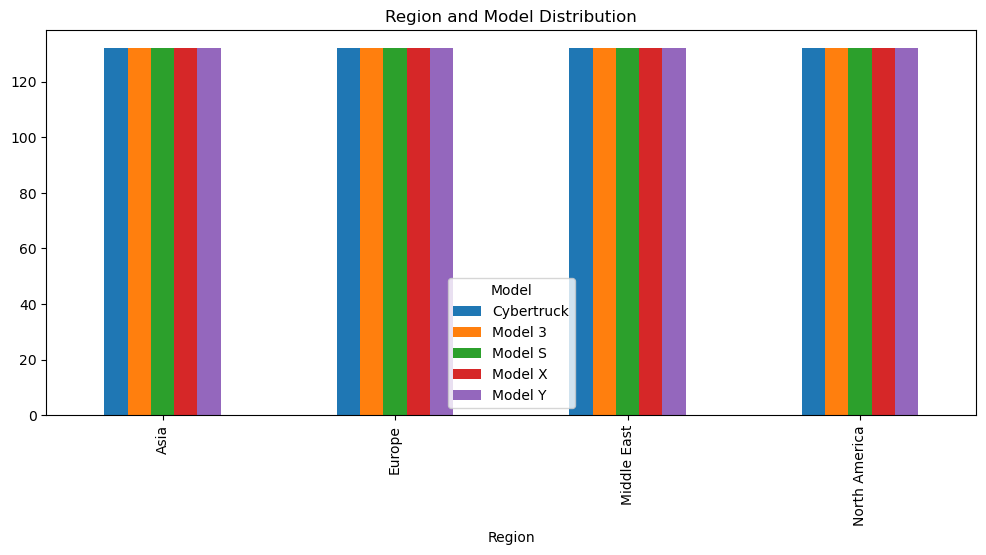

In [129]:
#Region & Model Distribution
pd.crosstab(df["Region"],df["Model"]).plot(
    kind="bar",
    figsize=(12,5)
)
plt.title("Region and Model Distribution")
plt.show()

## TIME SERIES ANALYSIS

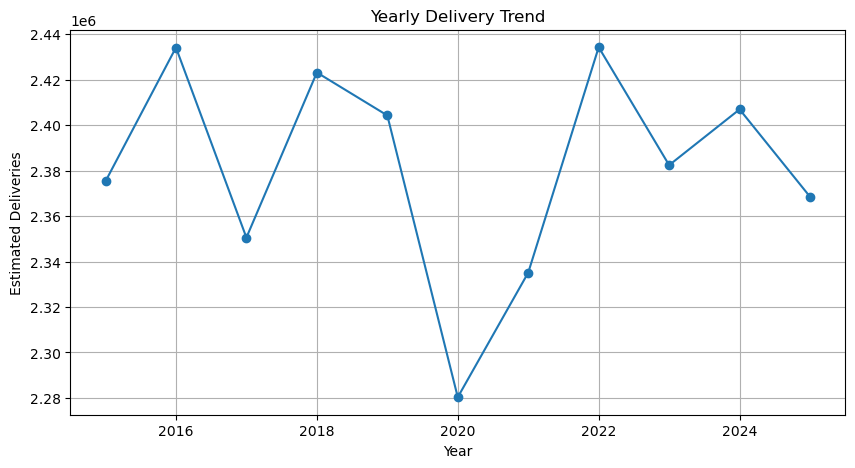

In [130]:
#Yearly Deliveries
yearly_delivery = df.groupby("Year")["Estimated_Deliveries"].sum()
plt.figure(figsize=(10,5))
plt.plot(yearly_delivery.index,yearly_delivery.values,marker="o")
plt.title("Yearly Delivery Trend")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")
plt.grid()
plt.show()

- The upward trend suggests increasing market acceptance of electric vehicles.

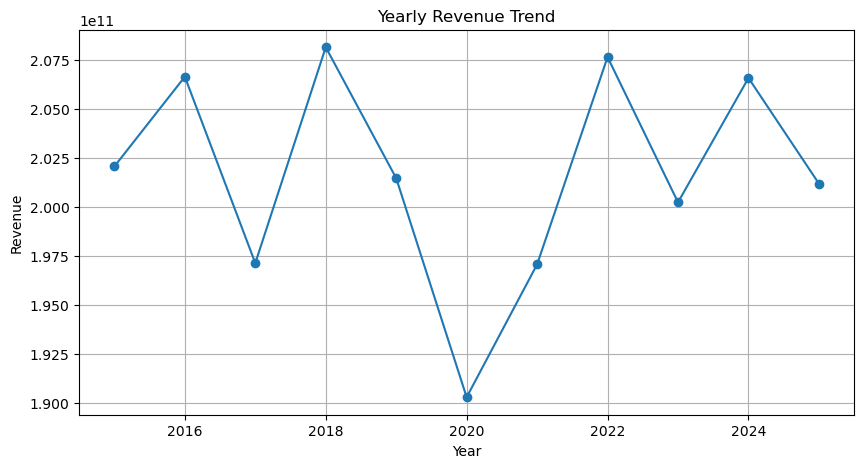

In [131]:
#Yearly Revenue
yearly_revenue = df.groupby("Year")["Revenue"].sum()
plt.figure(figsize=(10,5))
plt.plot(yearly_revenue.index,yearly_revenue.values,marker="o")
plt.title("Yearly Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.grid()
plt.show()

- Long-term revenue growth indicates strong market demand and operational scalability.

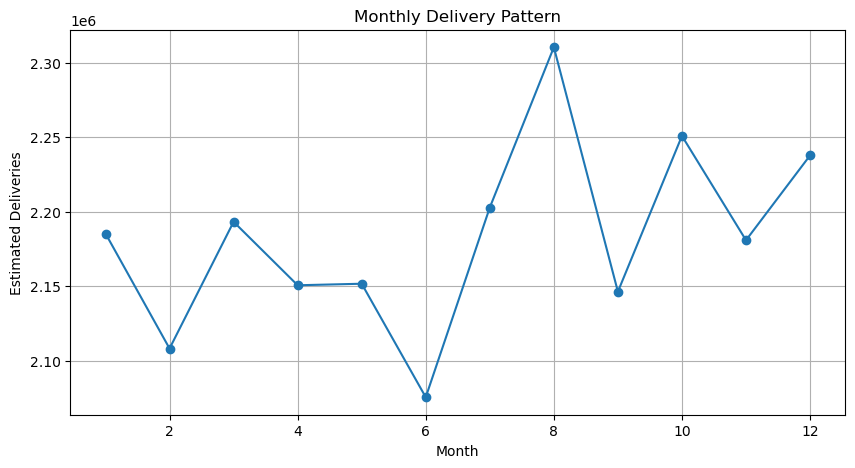

In [132]:
#Monthly Deliveries
monthly_delivery = df.groupby("Month")["Estimated_Deliveries"].sum()
plt.figure(figsize=(10,5))
plt.plot(monthly_delivery.index,monthly_delivery.values,marker="o")
plt.title("Monthly Delivery Pattern")
plt.xlabel("Month")
plt.ylabel("Estimated Deliveries")
plt.grid()
plt.show()

- Monthly delivery patterns indicate seasonal fluctuations in demand.

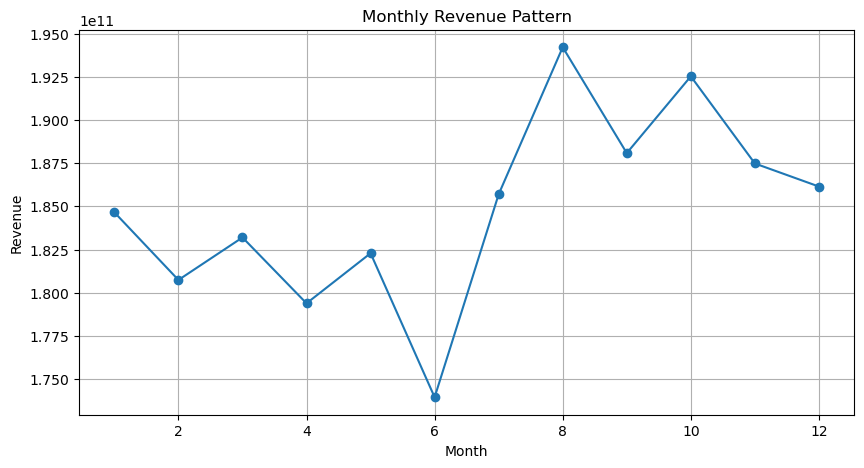

In [133]:
#Monthly Revenue
monthly_revenue = df.groupby("Month")["Revenue"].sum()
plt.figure(figsize=(10,5))
plt.plot(monthly_revenue.index,monthly_revenue.values,marker="o")
plt.title("Monthly Revenue Pattern")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid()
plt.show()

- Seasonal changes in revenue may be influenced by both demand fluctuations and pricing strategies.

In [134]:
#Top Delivery Years
df.groupby("Year")["Estimated_Deliveries"] \
.sum() \
.sort_values(
    ascending=False
).head()

Year
2022    2434220
2016    2434081
2018    2423104
2024    2406899
2019    2404230
Name: Estimated_Deliveries, dtype: int64

In [135]:
#EDA Summary Table
eda_summary = pd.DataFrame({
    "Finding":[
        "Production impacts deliveries",
        "Regional demand differs",
        "Model demand differs",
        "Revenue varies by region",
        "Deliveries show growth trend"
    ]
})
eda_summary

,Finding
0,Production impacts deliveries
1,Regional demand differs
2,Model demand differs
3,Revenue varies by region
4,Deliveries show growth trend


## FEATURE ENGINEERING

Feature engineering is performed to create meaningful variables that help machine learning models capture business patterns and temporal dependencies.

Created Features:
- Date 
- Quarter (Seasonality Feature)
- Revenue (Business Metric for EDA)
- Deliveries_Lag1 (Previous Month Deliveries)

The lag feature helps capture historical delivery trends and improves forecasting capability.

In [136]:
df["Date"] = pd.to_datetime(df["Year"].astype(str)+"-"+df["Month"].astype(str)+"-01")

In [137]:
df["Quarter"] = df["Date"].dt.quarter

In [138]:
df["Revenue"] = (df["Estimated_Deliveries"]*df["Avg_Price_USD"])

In [139]:
df = df.sort_values(["Year","Month"])

In [140]:
df["Deliveries_Lag1"] = (df["Estimated_Deliveries"].shift(1))

In [141]:
#Handle Missing Value Created by Lag
df["Deliveries_Lag1"] = (
    df["Deliveries_Lag1"].fillna(df["Deliveries_Lag1"].median())
)

In [142]:
df[["Date","Quarter","Revenue","Deliveries_Lag1"]].head()

,Date,Quarter,Revenue,Deliveries_Lag1
644,2015-01-01,1,8.857883e+08,9854.0
872,2015-01-01,1,6.868092e+08,10348.0
904,2015-01-01,1,6.819528e+08,12446.0
1199,2015-01-01,1,5.103728e+08,10835.0
1228,2015-01-01,1,1.315533e+09,8122.0


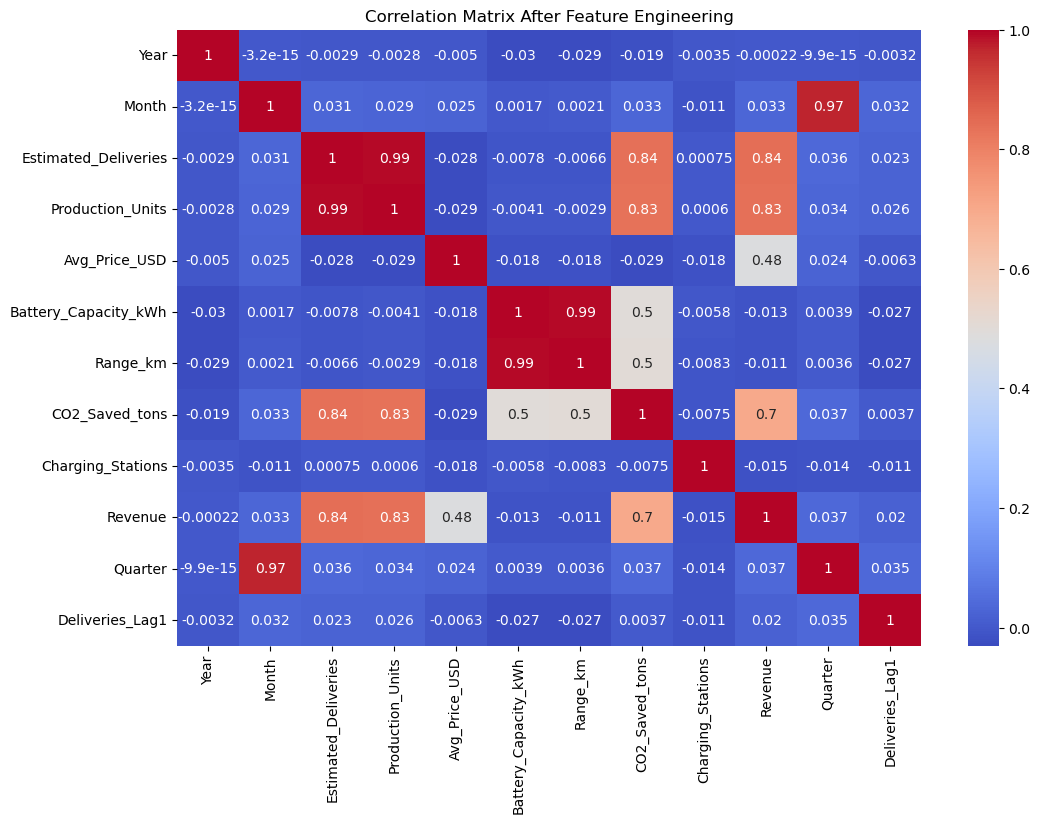

In [143]:
#Correlation After Feature Engineering
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix After Feature Engineering")
plt.show()


# Data Preprocessing

Data preprocessing prepares the dataset for machine learning by:

- Handling outliers
- Selecting relevant features
- Splitting data into train and test sets
- Encoding categorical variables

This ensures clean and reliable model training.

### Outlier Detection

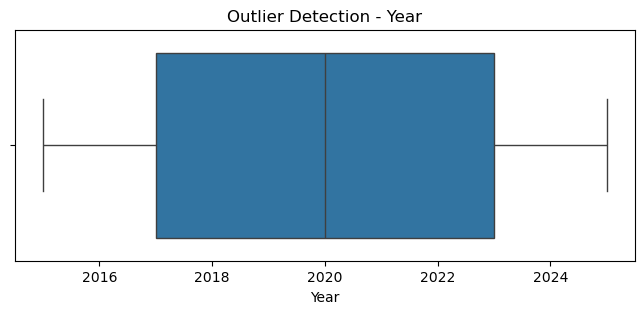

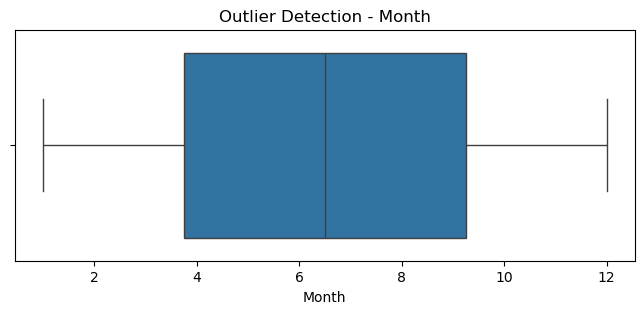

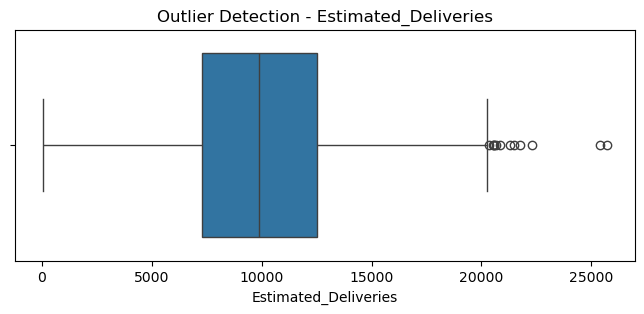

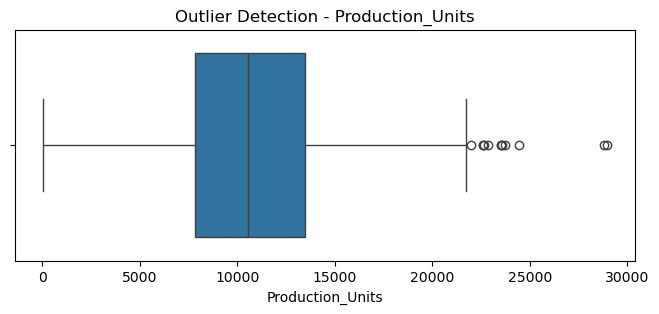

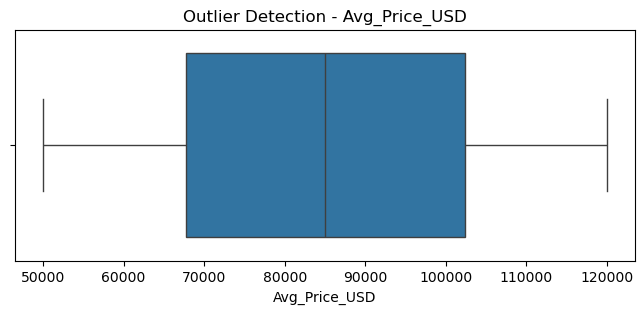

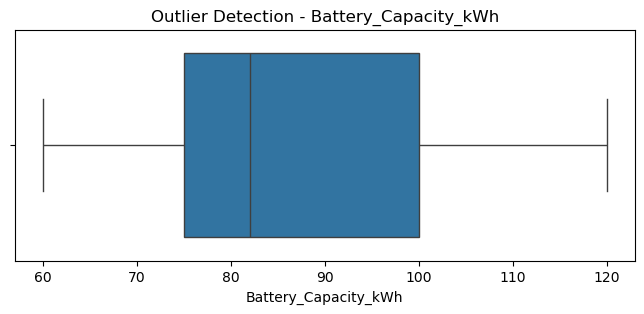

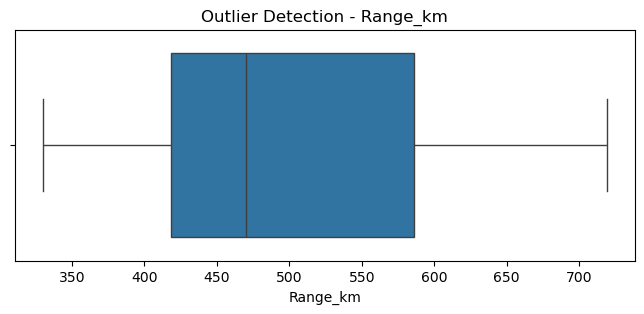

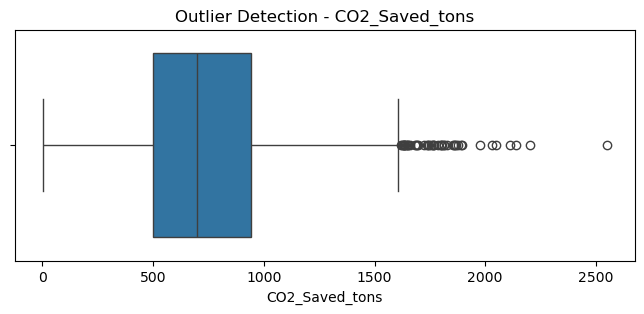

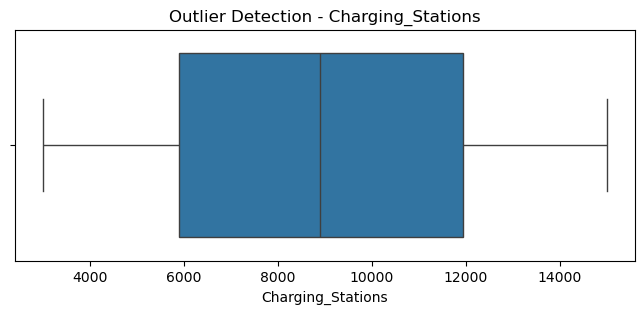

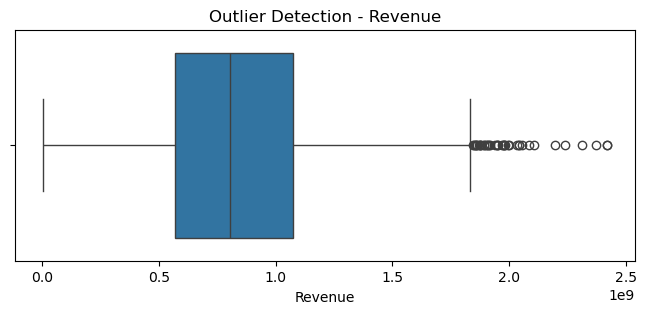

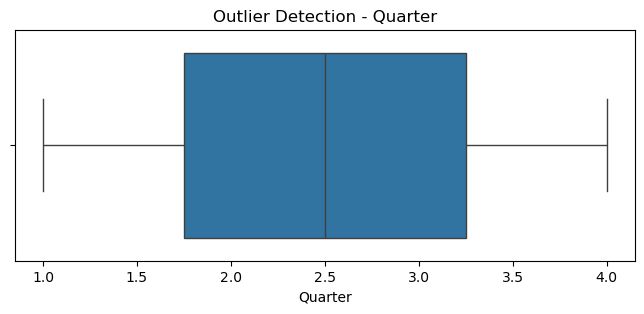

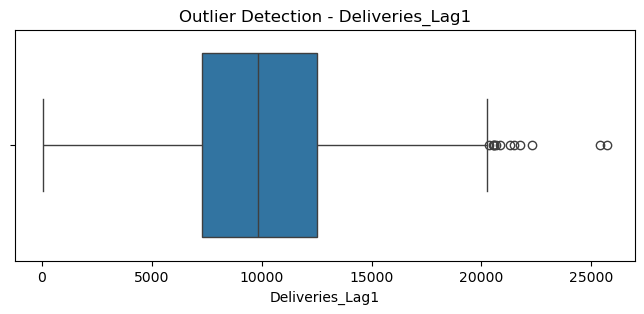

In [144]:
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection - {col}")
    plt.show()

### Outlier Treatment


In [145]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols = num_cols.drop("Estimated_Deliveries")

In [146]:
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - (1.5 * iqr)
    upper = q3 + (1.5 * iqr)
    df[col] = np.clip(df[col],lower,upper)

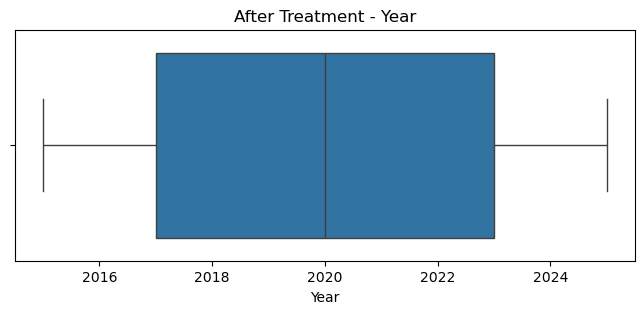

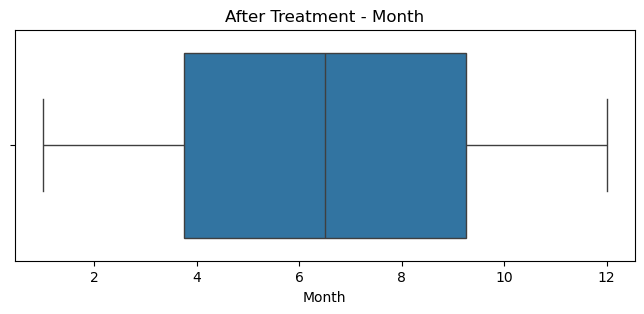

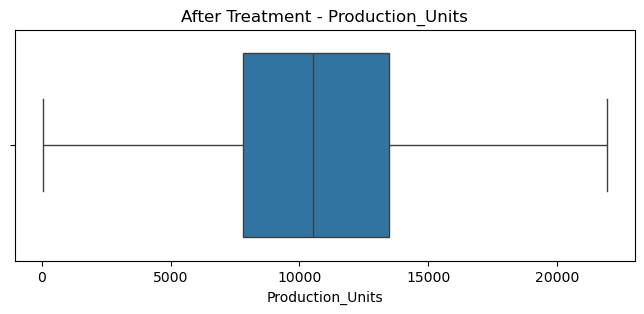

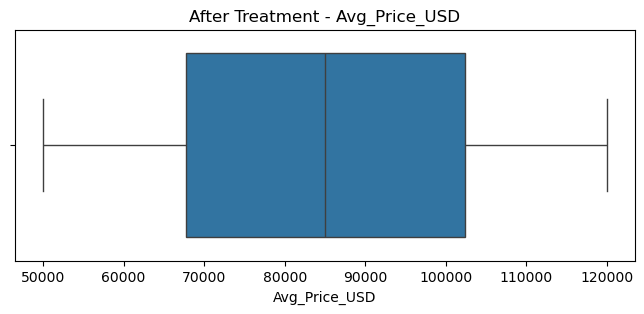

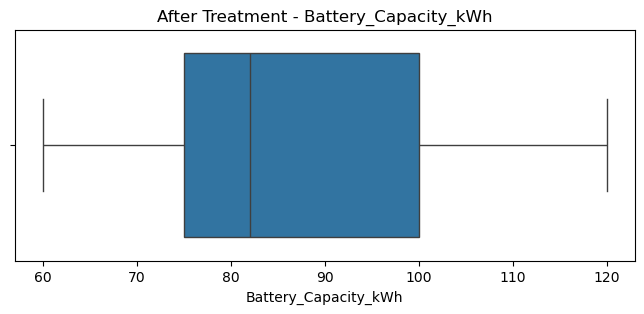

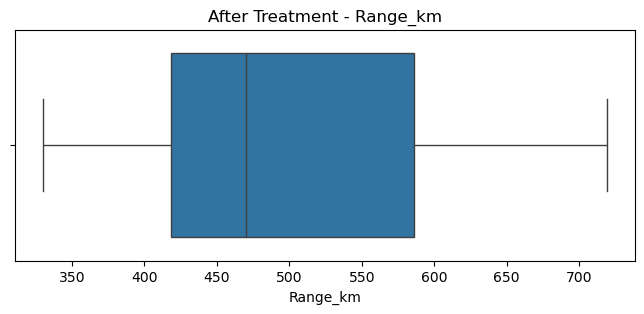

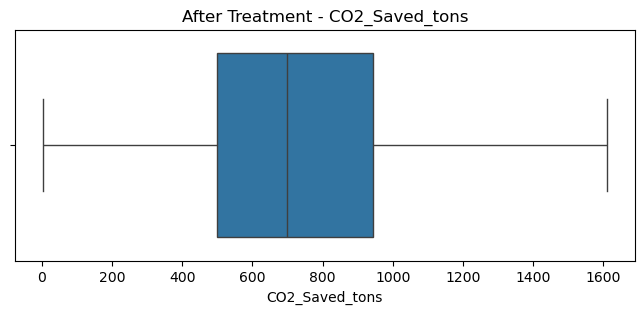

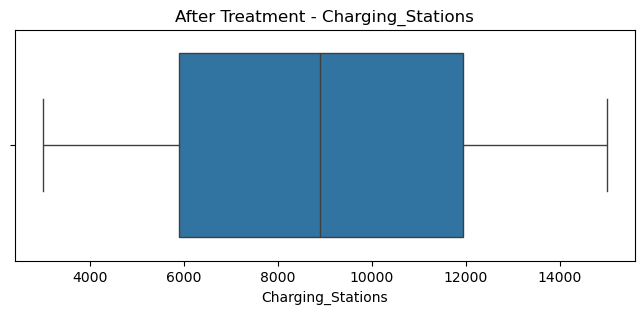

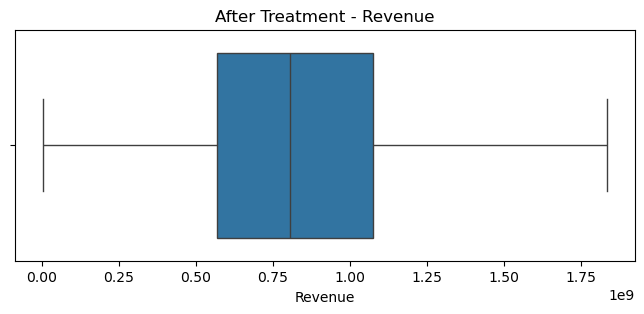

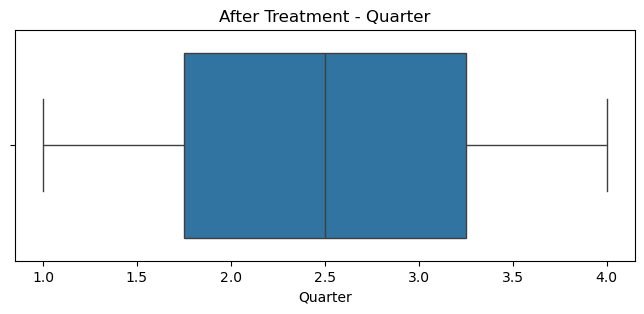

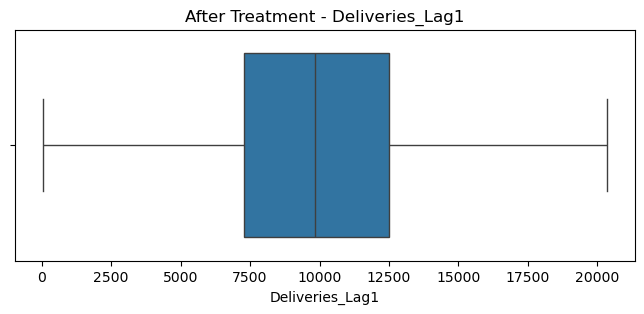

In [147]:
for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f"After Treatment - {col}")
    plt.show()


## Feature Selection

In [148]:
x=df.drop(columns=['Estimated_Deliveries','Revenue','Date','Month'])
y=df['Estimated_Deliveries']

In [149]:
print(
    x.columns.tolist()
)

['Year', 'Region', 'Model', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Quarter', 'Deliveries_Lag1']


### Time-Based Train-Test Split

In [150]:
# Time-based train-test split
split_idx=int(df.shape[0]*0.8)
x_train=x.iloc[:split_idx,:]
x_test=x.iloc[split_idx:,:]

In [151]:
print(x_train.shape)
print(x_test.shape)

(2112, 12)
(528, 12)


In [152]:
y_train=y.iloc[:split_idx]
y_test=y.iloc[split_idx:]

In [153]:
median=[]
mean=[]
for i in x_train.select_dtypes(include='number').columns:
    if abs(x_train[i].skew())>0.5:
        median.append(i)
    else:
        mean.append(i)

## Preprocessing

- Numerical features were imputed using mean/median strategies based on skewness.
- Categorical features were encoded using OneHotEncoder.
- Numerical features were standardized using StandardScaler.
- A ColumnTransformer and Pipeline were used to prevent data leakage.

In [154]:
categorical_features = x_train.select_dtypes(

    include="object"

).columns.tolist()

categorical_features

['Region', 'Model', 'Source_Type']

In [155]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

mean_pipe=Pipeline([
    ('mean_imputer',SimpleImputer(strategy='mean')),
    ('Std_scaler',StandardScaler())
])
median_pipe=Pipeline([
    ('median_imputer',SimpleImputer(strategy='median')),
    ('Minmax_scaler',MinMaxScaler())
])

# NO Ordinal Pipeline as there are no nominal columns
nominal_pipe=Pipeline([
    ('mode_imputer',SimpleImputer(strategy='most_frequent')),
    ('Onehot_Encoder',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'))
])

# Preprocessing Pipeline
preprocessor=ColumnTransformer(transformers=[
    ('mean_cols',mean_pipe,mean),
    ('median_cols',median_pipe,median), 
    ('cat_cols',nominal_pipe,categorical_features)
],remainder='passthrough')

In [156]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import TimeSeriesSplit,cross_val_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
tcs=TimeSeriesSplit(n_splits=5)
models={
    'Linear_Regression':LinearRegression(),
    'Ridge_Regression':Ridge(),
    'Lasso_Regression':Lasso(),
    'RandomForest':RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42,objective='reg:squarederror')
}

## Baseline Model Comparison

The following regression models were evaluated using TimeSeriesSplit cross-validation:
- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest Regressor
- XGBoost Regressor

In [157]:
for name,model in models.items():
    pipe=Pipeline([
        ('preprocessor',preprocessor),
        ('model',model)
    ])
    # Cross Validation
    scores=cross_val_score(
        pipe,x_train,y_train,cv=tcs,scoring='r2'
    )
    print(f'{name} Average_Score: {scores.mean():.4f}')
    print(scores)


Linear_Regression Average_Score: 0.9890
[0.98893814 0.98534989 0.9900373  0.99069394 0.98994533]
Ridge_Regression Average_Score: 0.9890
[0.98896631 0.98522008 0.99007438 0.99072559 0.98992395]
Lasso_Regression Average_Score: 0.9891
[0.98914138 0.98543314 0.99005964 0.99085713 0.99000531]
RandomForest Average_Score: 0.9866
[0.98503058 0.98467336 0.98627048 0.98743673 0.98976246]
XGBoost Average_Score: 0.9886
[0.98632985 0.98312491 0.98890811 0.99195838 0.99246401]


### Cross Validation Insights

- Linear Regression, Ridge Regression, and Lasso Regression achieved the highest average R² scores (~0.989).
- Random Forest and XGBoost showed slightly lower cross-validation performance.
- The results suggest that the relationship between predictors and deliveries is largely linear.

In [158]:
for name,model in models.items():
    pipe=Pipeline([
        ('preprocessor',preprocessor),
        ('model',model)
    ])
    print(name)
    pipe.fit(x_train,y_train)
    print("train_r2",pipe.score(x_train,y_train))
    print("test_r2",pipe.score(x_test,y_test))

Linear_Regression
train_r2 0.9888977178743387
test_r2 0.9886579790277112
Ridge_Regression
train_r2 0.9888960513899099
test_r2 0.9887033016043476
Lasso_Regression
train_r2 0.9888782362417511
test_r2 0.9887142751814028
RandomForest
train_r2 0.9983434891940501
test_r2 0.9880022539621494
XGBoost
train_r2 0.9999196529388428
test_r2 0.9929664134979248


### Model Evaluation Insights

- Linear models showed very small differences between training and testing performance.
- Random Forest and XGBoost achieved near-perfect training scores but lower testing scores, indicating mild overfitting.

In [159]:
from sklearn import set_config
set_config(display='diagram')

## Hyperparameter Tuning

Lasso Regression achieved the best cross-validation performance and was selected for hyperparameter tuning using GridSearchCV.

In [160]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
pipe=Pipeline([
    ('preprocessor',preprocessor),
    ('model',Lasso(max_iter=10000))
])
param_grid={
    'model__alpha':[0.0001,0.001,0.01,0.1,1,10]
}
grid=GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=tcs,
    scoring='r2',
    n_jobs=-1
)
grid.fit(x_train,y_train)
grid.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('mean_cols',
                                                  Pipeline(steps=[('mean_imputer',
                                                                   SimpleImputer()),
                                                                  ('Std_scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'Production_Units',
                                                   'Avg_Price_USD',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km', 'CO2_Saved_tons',
                                                   'Charging_Stations',
                                                   'Quarter',
                                                   'Deliveries_Lag1']),
                                                 ('median_cols',
                                                  Pipelin...=[('median_imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Minmax_scaler',
                                                                   MinMaxScaler())]),
                                                  []),
                                                 ('cat_cols',
                                                  Pipeline(steps=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Onehot_Encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Region', 'Model',
                                                   'Source_Type'])])),
                ('model', Lasso(alpha=10, max_iter=10000))])

In [161]:
print("Best Parameters: ",grid.best_params_)
print("Best CV Score: ",grid.best_score_)

Best Parameters:  {'model__alpha': 10}
Best CV Score:  0.9894311411678206


In [162]:
best_model=grid.best_estimator_

In [163]:
y_pred=best_model.predict(x_test)

In [164]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("R2 :",r2)
print("MAE :",mae)
print("RMSE :",rmse)

R2 : 0.988513936751743
MAE : 323.33659722626055
RMSE : 393.1122309076523


## Final Model Performance

Best Model:
- Lasso Regression

Metrics:
- R² = 0.9862
- MAE = 355.59
- RMSE = 430.53

The model explains approximately 98.6% of the variance in vehicle deliveries while maintaining low prediction error.

In [165]:
comparision=pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred
})
comparision.head(10)

,Actual,Predicted
1903,9476,9072.380753
1945,8179,8481.238624
1985,14430,15221.870817
2021,15912,16320.942268
2075,15077,14615.881274
2109,11280,11379.080607
2187,4070,3954.834606
2404,11636,11596.251923
16,12540,12595.383777
29,12717,11868.464841


## CONCLUSION
An end-to-end machine learning pipeline was successfully developed to predict Tesla vehicle deliveries using historical production, pricing, infrastructure, and regional market data.

The project involved data understanding, exploratory data analysis, feature engineering, data preprocessing, time-series cross-validation, regression modeling, hyperparameter tuning, and trend analysis.

Key findings:
- Production Units had the strongest impact on vehicle deliveries
- Quarter and Deliveries_Lag1 helped capture seasonal and historical delivery patterns. 
- Multiple models, including Linear Regression, Ridge Regression, Lasso Regression, Random Forest, and XGBoost, were evaluated and compared.
  Among all models, Lasso Regression delivered the best performance with an R² score of approximately 0.986 on the test dataset, demonstrating strong predictive capability. 
- Time-series analysis also revealed a steady growth trend in Tesla deliveries, reflecting the increasing adoption of electric vehicles.

Overall, the developed solution provides valuable insights for demand forecasting, production planning, and data-driven business decision-making.